<a href="https://colab.research.google.com/github/angelalexanderlopez176-a11y/2026MusicComputingClasswork/blob/main/assignments/labAssignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import IPython.display
import librosa
import scipy.signal as sg

# import audio files
!git clone https://github.com/jcdevaney/musicComputing2026.git

fatal: destination path 'musicComputing2026' already exists and is not an empty directory.


In [15]:
  # copy from filters.ipynb
def plotTimeFreq(sig,sr,title,winSize,specType,fig):

    plt.figure(fig)


    plt.subplot(2,1,1)
    time = np.arange(0,sig.shape[0])/sr
    plt.plot(time,sig)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(title)


    plt.subplot(2,1,2)
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig,n_fft=winSize)), ref=np.max)

    librosa.display.specshow(spec,sr=sr,x_axis='time',y_axis='hz')

    plt.ylabel('Hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)

    plt.show()

In [16]:
def filterSignal(sig,sr,freq,filtType,order,winSize,specType,fig):

  if filtType == 'low' or filtType == 'high':
    filterFreq = freq/(sr/2)

  elif filtType == 'bandpass' or filtType == 'bandstop':
    filterFreq = [freq[0]/(sr/2), freq[1]/(sr/2)]

  b,a = sg.butter(order,filterFreq,btype=filtType)

  sigFilt = sg.filtfilt(b,a,sig)

  plotTimeFreq(sigFilt,sr,filtType,winSize,specType,fig)

  return sigFilt

    # Inputs
    #   - signal to filter (sig)
    #   - sampling rate of the signal (sr)
    #   - filter frequency/frequencies (freq)
    #   - filter type (filtType)
    #   - order of the filter (order)
    #   - window size for the FFT (winSize)
    #   - type of spectrogram, log or linear (specType)
    #   - figure number (fig)

    # use an if/elif/else statement with ‘or’ tests to set up the parameters for the different   type of filter based on the code in filters.ipynb and or.ipynb, specifically
	  #   if the filter type is ‘low’ or ‘high’
		#       filterFreq = freq / (sr / 2)
	  #   if the filter type if ‘bandpass’ or ‘bandstop’
		#       filterFreq = [freq[0] / (sr / 2), freq[1] / (sr / 2)]

    # create a filter using using sg.butter()

    # run the created filter on the inputting signal using sg.filtfilt()

    # plot the filtered signal with plotTimeFreq(), use filtType for title

    # return the filtered signal


In [17]:
def allFilters(sig,sr,freq,width,order,winSize,specType):


  fig = 1
  sig_lp = filterSignal(sig,sr,freq,'low',order,winSize,specType,fig)


  fig = 2
  sig_hp = filterSignal(sig,sr,freq,'high',order,winSize,specType,fig)


  fig = 3
  bandFreq = [freq-width,freq+width]
  sig_bp = filterSignal(sig,sr,bandFreq,'bandpass',order,winSize,specType,fig)


  fig = 4
  sig_bs = filterSignal(sig,sr,bandFreq,'bandstop',order,winSize,specType,fig)

  return sig_lp,sig_hp,sig_bp,sig_bs

    # Inputs
    #   - signal to filter (sig)
    #   - sampling rate of the signal (sr)
    #   - filter frequency (freq)
    #   - distance between the low and high band frequencies (width)
    #   - order of the filter (order)
    #   - window size for the FFT (winSize)
    #   - type of spectrogram, log or linear (specType)

    # call filterSignal() to run a low-pass filter on the inputting signal using
    # the inputting filter frequency and filter order
    # set fig equal to 1


    # call filterSignal() to run a high-pass filter on the inputting signal
    # using the inputting filter frequency and filter order
    # set fig equal to 2

    #call filterSignal() to run a band-pass filter on the inputting signal using
    # the inputting filter frequency and filter order – filter frequency will be
    # calculated using the inputted width parameter like this:
    #                   [freq-width,freq+width]
    # set fig equal to 3

    # call filterSignal() to run a band-stop filter on the inputting signal using
    # the inputting filter frequency and filter order – filter frequency will be
    # calculated using the inputted width parameter like this:
    #                   [freq-width,freq+width]
    # set fig equal to 4


    # return the output of the low-pass, high-pass, bandpass, and bandstop
    # filtered signals


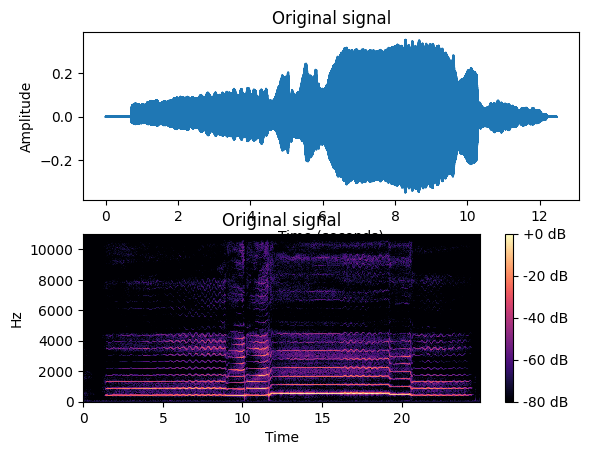

In [18]:
# load original signal
sig , sr = librosa.load('musicComputing2026/audioFiles/avm.wav')
winSize = 1024
specType = 'log'
fig = 1

plotTimeFreq(sig,sr,'Original signal',winSize,specType,fig)

IPython.display.Audio(data=sig,rate=sr)

# Plot original signal with plotTimeFreq()

# Play original signal with IPython.display.Audio()

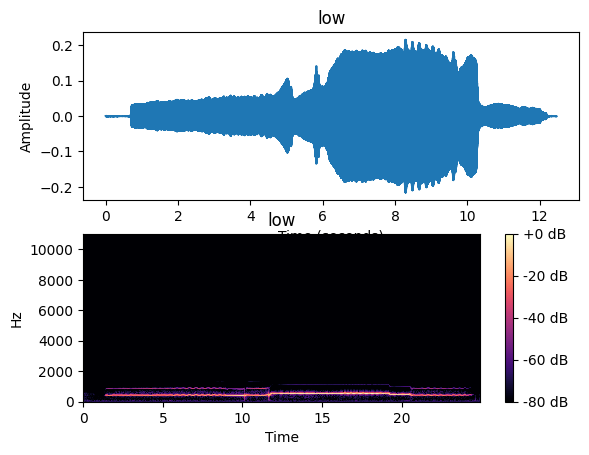

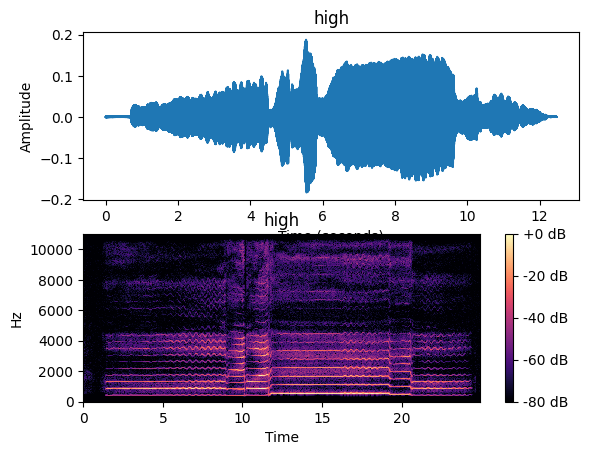

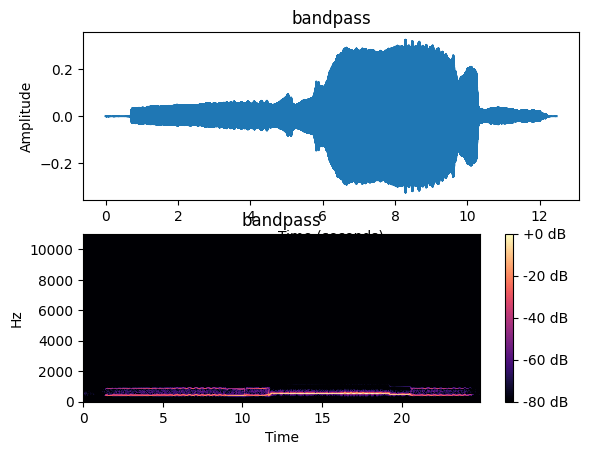

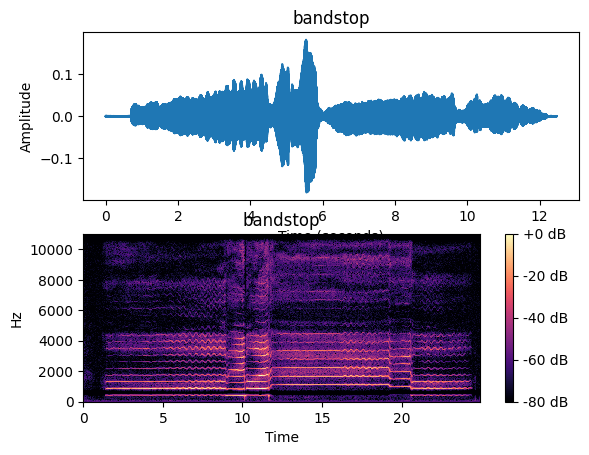

In [19]:
freq = 600
width = 200
order = 4

sig_lp,sig_hp,sig_bp,sig_bs = allFilters(sig,sr,freq,width,order,winSize,specType)

# call allFilters() and save the output as sig_lp, sig_hp, sig_bp, sig_bs

In [20]:
IPython.display.Audio(data=sig_lp,rate=sr)
IPython.display.Audio(data=sig_hp,rate=sr)
IPython.display.Audio(data=sig_bp,rate=sr)
IPython.display.Audio(data=sig_bs,rate=sr)

In [21]:
# play the low-pass version of the signal with IPython.display.Audio()


In [22]:
# play the high-pass version of the signal with IPython.display.Audio()


In [23]:
# play the band-pass version of the signal with IPython.display.Audio()


In [24]:
# play the band-stop version of the signal with IPython.display.Audio()
